# **Seventh LangGraph**

## **Boilerplate**

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ["OPENAI_API_KEY"]:
    print("OpenAI api key set")
else:
    raise ValueError("OpenAI api key is not set")

OpenAI api key set


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

## **Type Dict Schema**

In [ ]:
from typing import TypedDict, Annotated
import operator

class graph_schema(TypedDict):

    topic: str
    insta: str
    twitter: str
    linkedin: str

## **Create Graph Nodes**

In [ ]:
def create_post_insta(state: graph_schema) -> graph_schema:

    topic = state['topic']

    post = llm.invoke(f"write an instagram post about {topic}").content
    
    return {'insta': post}

def create_post_twitter(state: graph_schema) -> graph_schema:

    topic = state['topic']

    post = llm.invoke(f"write a twitter post about {topic}").content

    state['twitter'] = post
    
    return {'twitter': post}

def create_post_linkedin(state: graph_schema) -> graph_schema:

    topic = state['topic']

    post = llm.invoke(f"write a linkedin post about {topic}").content

    state['linkedin'] = post
    
    return {'linkedin': post}

## **Create Graph w/ Parallel Nodes**

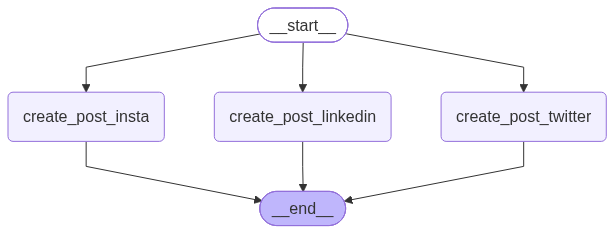

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedin", create_post_linkedin)

# add parallel edges to each node:

graph.add_edge(START, "create_post_insta")
graph.add_edge(START, "create_post_twitter")
graph.add_edge(START, "create_post_linkedin")
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedin", END)

# compile graph
parallel_graph = graph.compile()

# display graph
from IPython.display import Image, display

Image(parallel_graph.get_graph().draw_mermaid_png())




## **Invoke Graph**

In [9]:
parallel_graph.invoke({
    "topic": "my new job at the chair company",
    "insta": "",
    "twitter": "",
    "linkedin": ""
})

InvalidUpdateError: Expected dict, got 🎉 Exciting news! I’m thrilled to announce that I’ve joined the amazing team at [Chair Company Name]! 🪑✨ Can’t wait to contribute to creating innovative designs that redefine comfort and style. Here’s to new beginnings and great adventures ahead! #NewJob #ChairCompany #DesignLife
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE